# Kerala Cities GeoDataFrame
Create a GeoDataFrame with:
Kerala district, their latitude and longitude

## Tasks:
- Create geometry column
- Set city as index
- Plot cities
- Find centroid
- Create 20 km buffer
- Save as GeoJSON

## Concepts
- Pandas
- GeoDataFrame
- Buffer
- Plotting

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [44]:
url=r"C:\Users\aksha\Projects\py-library_pract\np+pd+gpd\data\Kerala_District_Boundary.geojson"
gdf=gpd.read_file(url)
gdf.head()
gdf.columns

Index(['FID', 'DISTRICT', 'Area', 'Perimeter', 'Shape__Area', 'Shape__Length',
       'GlobalID', 'geometry'],
      dtype='str')

<Axes: >

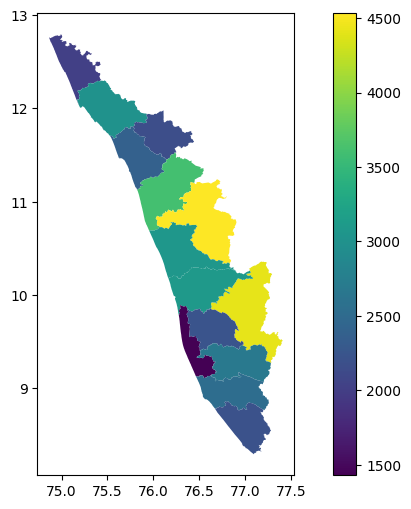

In [45]:
gdf.plot(
    "Area",
    legend=True,
    figsize=(10,6)
)

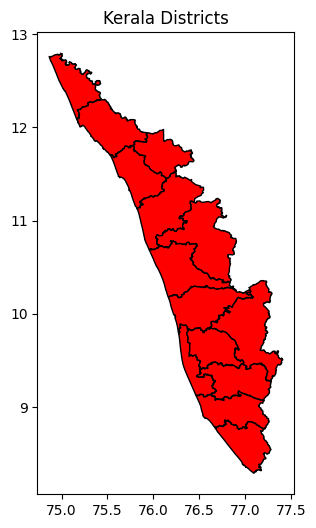

In [46]:
gdf.plot(
    color="red",
    edgecolor="black",
    figsize=(10,6)
)
plt.title("Kerala Districts")
plt.show()

In [47]:
gdf.crs
gdf_proj=gdf.to_crs(epsg=3857)#better for centroid calculation

In [48]:
gdf_proj["centroid"]=gdf_proj.centroid
gdf_proj.head()

,FID,DISTRICT,Area,Perimeter,Shape__Area,Shape__Length,GlobalID,geometry,centroid
0,1,Kasaragod,2016.157,341.347,2.101795e+09,350844.488395,a99e5deb-b257-4e84-ba75-272195ef0c57,"POLYGON ((8348064.099 1436243.291, 8348375.792...",POINT (8365864.04 1398282.022)
1,2,Kannur,3008.336,311.923,3.125031e+09,319812.839640,fb9a592c-1970-4f9b-9aac-8bf0f035a4be,"POLYGON ((8401471.5 1379676.991, 8401517.362 1...",POINT (8407365.963 1345663.166)
2,3,Wayanad,2156.529,283.003,2.235390e+09,289844.226264,ef410d74-9f31-4cea-bd70-b748a6a8121b,"POLYGON ((8472843.301 1341946.841, 8472841.603...",POINT (8471262.422 1312873.507)
3,4,Kozhikode,2376.057,290.149,2.458910e+09,297071.479203,147cb301-875a-4e25-8ec1-6fe73885b711,"POLYGON ((8434341.121 1323207.152, 8434384.435...",POINT (8441798.676 1287144.43)
4,5,Malappuram,3599.694,394.870,3.715955e+09,403735.786114,e3ec54ba-6749-4fba-9d3c-c28c958e241e,"POLYGON ((8487655.099 1290616.629, 8487723.892...",POINT (8477604.533 1247128.883)


In [49]:
gdf["centroid"]=gdf_proj["centroid"].to_crs(epsg=4326)

In [50]:
gdf["Latitude"]=gdf["centroid"].y
gdf["Longitude"]=gdf["centroid"].x
gdf[["DISTRICT", "Latitude", "Longitude"]]

,DISTRICT,Latitude,Longitude
0,Kasaragod,12.461556,75.151835
1,Kannur,11.999602,75.524653
2,Wayanad,11.711331,76.098645
3,Kozhikode,11.484923,75.833968
4,Malappuram,11.132436,76.155617
5,Palakkad,10.794677,76.557431
6,Thrissur,10.470915,76.315897
7,Idukki,9.838749,77.057750
8,Ernakulam,10.083274,76.546854
9,Alappuzha,9.426131,76.448925


In [51]:
gdf=gdf.set_index("DISTRICT")

In [52]:
gdf_proj["buffer"]=gdf_proj.buffer(20000)

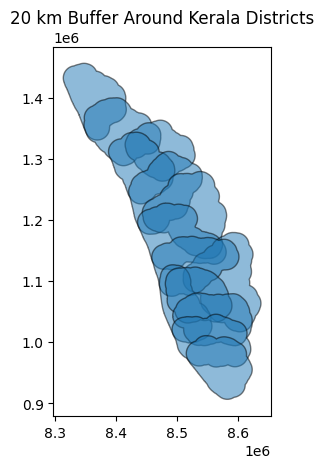

In [53]:
gdf_proj["buffer"].plot(
    alpha=0.5,
    edgecolor="black"
)
plt.title("20 km Buffer Around Kerala Districts")
plt.show()

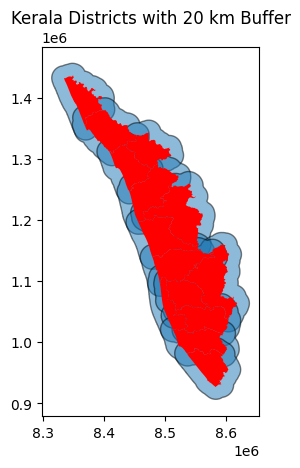

In [54]:
ax = gdf_proj["buffer"].plot(
    alpha=0.5,
    edgecolor="black"
)

gdf_proj["geometry"].plot(
    ax=ax,
    color="red"
)

plt.title("Kerala Districts with 20 km Buffer")
plt.show()